**1. Data Loading and preprocessing**

In [1]:
import pandas as pd
import numpy as np
import re
import json
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter
import datetime
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse

In [2]:
# Load the TSV file without setting custom column names to retain the original header
behaviors_df = pd.read_csv("../data/raw/MINDsmall_train/behaviors.tsv", sep="\t", header=None)

# 1️⃣ Handle Missing Values
# Option 1: Drop rows with missing 'history'
behaviors_df.dropna(subset=[3], inplace=True)  # Adjust index based on the original structure

# 2️⃣ Convert 'time' to datetime
behaviors_df[2] = pd.to_datetime(behaviors_df[2])  # Convert time column (index 2)

# 3️⃣ Convert 'history' to a list of news IDs
behaviors_df[3] = behaviors_df[3].apply(
    lambda x: x.split() if isinstance(x, str) and x.strip() else []
)

# 4️⃣ Convert 'impressions' to a list of tuples
behaviors_df[4] = behaviors_df[4].apply(
    lambda x: [(item.split('-')[0], int(item.split('-')[1])) for item in x.split()] if pd.notna(x) else []
)

# 5️⃣ Expand 'impressions' into separate rows
expanded_rows = []
for _, row in behaviors_df.iterrows():
    impression_id = int(row[0])  # Convert Impression ID to integer
    user_id = str(row[1])        # Convert User ID to string
    timestamp = row[2]           # Already a datetime object
    history = row[3]             # List of news IDs
    # Extract impressions
    impressions = row[4]         # List of (news_id, label) tuples
    for news_id, label in impressions:
        expanded_rows.append([impression_id, user_id, timestamp, history, news_id, label])

# Create a new DataFrame with expanded impressions
expanded_behaviors_df = pd.DataFrame(expanded_rows, columns=['impression_id', 'user_id', 'time', 'history', 'news_id', 'label'])

# Ensure correct data types
expanded_behaviors_df['impression_id'] = expanded_behaviors_df['impression_id'].astype(int)
expanded_behaviors_df['user_id'] = expanded_behaviors_df['user_id'].astype(str)
expanded_behaviors_df['time'] = pd.to_datetime(expanded_behaviors_df['time'])
# Convert 'history' to a list of strings
expanded_behaviors_df['history'] = expanded_behaviors_df['history'].apply(
    lambda x: list(x) if isinstance(x, list) else []
)
expanded_behaviors_df['news_id'] = expanded_behaviors_df['news_id'].astype(str)
expanded_behaviors_df['label'] = expanded_behaviors_df['label'].astype(int)

# Display the DataFrame to verify the changes
print(expanded_behaviors_df.head())
print(expanded_behaviors_df.info())

   impression_id user_id                time  \
0              1  U13740 2019-11-11 09:05:58   
1              1  U13740 2019-11-11 09:05:58   
2              2  U91836 2019-11-12 18:11:30   
3              2  U91836 2019-11-12 18:11:30   
4              2  U91836 2019-11-12 18:11:30   

                                             history news_id  label  
0  [N55189, N42782, N34694, N45794, N18445, N6330...  N55689      1  
1  [N55189, N42782, N34694, N45794, N18445, N6330...  N35729      0  
2  [N31739, N6072, N63045, N23979, N35656, N43353...  N20678      0  
3  [N31739, N6072, N63045, N23979, N35656, N43353...  N39317      0  
4  [N31739, N6072, N63045, N23979, N35656, N43353...  N58114      0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5723002 entries, 0 to 5723001
Data columns (total 6 columns):
 #   Column         Dtype         
---  ------         -----         
 0   impression_id  int64         
 1   user_id        object        
 2   time           datetime64[ns]
 3  

In [3]:
# Renaming the DataFrame from expanded_behaviors_df to behaviors_df
behaviors_df = expanded_behaviors_df.copy()

# Displaying the renamed DataFrame and its info to verify the changes
behaviors_df.head(), behaviors_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5723002 entries, 0 to 5723001
Data columns (total 6 columns):
 #   Column         Dtype         
---  ------         -----         
 0   impression_id  int64         
 1   user_id        object        
 2   time           datetime64[ns]
 3   history        object        
 4   news_id        object        
 5   label          int64         
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 262.0+ MB


(   impression_id user_id                time  \
 0              1  U13740 2019-11-11 09:05:58   
 1              1  U13740 2019-11-11 09:05:58   
 2              2  U91836 2019-11-12 18:11:30   
 3              2  U91836 2019-11-12 18:11:30   
 4              2  U91836 2019-11-12 18:11:30   
 
                                              history news_id  label  
 0  [N55189, N42782, N34694, N45794, N18445, N6330...  N55689      1  
 1  [N55189, N42782, N34694, N45794, N18445, N6330...  N35729      0  
 2  [N31739, N6072, N63045, N23979, N35656, N43353...  N20678      0  
 3  [N31739, N6072, N63045, N23979, N35656, N43353...  N39317      0  
 4  [N31739, N6072, N63045, N23979, N35656, N43353...  N58114      0  ,
 None)

In [4]:
behaviors_df

,impression_id,user_id,time,history,news_id,label
0,1,U13740,2019-11-11 09:05:58,"[N55189, N42782, N34694, N45794, N18445, N6330...",N55689,1
1,1,U13740,2019-11-11 09:05:58,"[N55189, N42782, N34694, N45794, N18445, N6330...",N35729,0
2,2,U91836,2019-11-12 18:11:30,"[N31739, N6072, N63045, N23979, N35656, N43353...",N20678,0
3,2,U91836,2019-11-12 18:11:30,"[N31739, N6072, N63045, N23979, N35656, N43353...",N39317,0
4,2,U91836,2019-11-12 18:11:30,"[N31739, N6072, N63045, N23979, N35656, N43353...",N58114,0
...,...,...,...,...,...,...
5722997,156964,U44625,2019-11-13 14:57:02,"[N4118, N47297, N3164, N43295, N6056, N38747, ...",N39317,0
5722998,156965,U64800,2019-11-14 15:25:49,"[N22997, N48742]",N61233,0
5722999,156965,U64800,2019-11-14 15:25:49,"[N22997, N48742]",N33828,1
5723000,156965,U64800,2019-11-14 15:25:49,"[N22997, N48742]",N19661,0


In [5]:
behaviors_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5723002 entries, 0 to 5723001
Data columns (total 6 columns):
 #   Column         Dtype         
---  ------         -----         
 0   impression_id  int64         
 1   user_id        object        
 2   time           datetime64[ns]
 3   history        object        
 4   news_id        object        
 5   label          int64         
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 262.0+ MB


In [6]:
# Load the dataset
news_df = pd.read_csv("../data/raw/MINDsmall_train/news.tsv", sep="\t", header=None)

# Define column names based on your description
news_df.columns = ['news_id', 'category', 'subcategory', 'title', 'abstract', 
                   'url', 'title_entities', 'abstract_entities']

# 1️⃣ Handle Missing Values
# Fill missing title and abstract with placeholders or drop them
news_df['title'].fillna("No Title Available", inplace=True)
news_df['abstract'].fillna("No Abstract Available", inplace=True)

# 2️⃣ Convert JSON-like entity columns to actual lists
def parse_entities(x):
    try:
        return json.loads(x) if pd.notna(x) and x.strip() else []
    except json.JSONDecodeError:
        return []

news_df['title_entities'] = news_df['title_entities'].apply(parse_entities)
news_df['abstract_entities'] = news_df['abstract_entities'].apply(parse_entities)

# 3️⃣ Text Preprocessing
def clean_text(text):
    """Clean the text by removing unwanted characters and converting to lowercase."""
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)  # Remove special characters
    return text.lower().strip()  # Convert to lowercase and remove extra spaces

news_df['title'] = news_df['title'].apply(clean_text)
news_df['abstract'] = news_df['abstract'].apply(clean_text)

# 4️⃣ Normalize Data
# Convert news_id to string (if necessary) to maintain consistent data types
news_df['news_id'] = news_df['news_id'].astype(str)

C:\Users\rafi_\AppData\Local\Temp\ipykernel_8228\1689551696.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  news_df['title'].fillna("No Title Available", inplace=True)
C:\Users\rafi_\AppData\Local\Temp\ipykernel_8228\1689551696.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a cop

In [7]:
news_df

,news_id,category,subcategory,title,abstract,url,title_entities,abstract_entities
0,N55528,lifestyle,lifestyleroyals,the brands queen elizabeth prince charles and ...,shop the notebooks jackets and more that the r...,https://assets.msn.com/labs/mind/AAGH0ET.html,"[{'Label': 'Prince Philip, Duke of Edinburgh',...",[]
1,N19639,health,weightloss,50 worst habits for belly fat,these seemingly harmless habits are holding yo...,https://assets.msn.com/labs/mind/AAB19MK.html,"[{'Label': 'Adipose tissue', 'Type': 'C', 'Wik...","[{'Label': 'Adipose tissue', 'Type': 'C', 'Wik..."
2,N61837,news,newsworld,the cost of trumps aid freeze in the trenches ...,lt ivan molchanets peeked over a parapet of sa...,https://assets.msn.com/labs/mind/AAJgNsz.html,[],"[{'Label': 'Ukraine', 'Type': 'G', 'WikidataId..."
3,N53526,health,voices,i was an nba wife heres how it affected my men...,i felt like i was a fraud and being an nba wif...,https://assets.msn.com/labs/mind/AACk2N6.html,[],"[{'Label': 'National Basketball Association', ..."
4,N38324,health,medical,how to get rid of skin tags according to a der...,they seem harmless but theres a very good reas...,https://assets.msn.com/labs/mind/AAAKEkt.html,"[{'Label': 'Skin tag', 'Type': 'C', 'WikidataI...","[{'Label': 'Skin tag', 'Type': 'C', 'WikidataI..."
...,...,...,...,...,...,...,...,...
51277,N16909,weather,weathertopstories,adapting learning and soul searching reflectin...,woolsey fire anniversary a community is foreve...,https://assets.msn.com/labs/mind/BBWzQJK.html,"[{'Label': 'Woolsey Fire', 'Type': 'N', 'Wikid...","[{'Label': 'Woolsey Fire', 'Type': 'N', 'Wikid..."
51278,N47585,lifestyle,lifestylefamily,family says 13yearold broadway star died from ...,no abstract available,https://assets.msn.com/labs/mind/BBWzQYV.html,"[{'Label': 'Broadway theatre', 'Type': 'F', 'W...",[]
51279,N7482,sports,more_sports,st dominic soccer player tries to kick cancer ...,sometimes what happens on the sidelines can be...,https://assets.msn.com/labs/mind/BBWzQnK.html,[],[]
51280,N34418,sports,soccer_epl,how the sounders won mls cup,mark jeremiah and casey were so excited they d...,https://assets.msn.com/labs/mind/BBWzQuK.html,"[{'Label': 'MLS Cup', 'Type': 'U', 'WikidataId...",[]


In [8]:
# Improved Temporal Split
def improved_temporal_split(behaviors_df, test_size=0.2, min_history=3):
    """Split ensuring users have history in both train and test sets"""
    # Sort by time
    behaviors_df = behaviors_df.sort_values('time')
    
    # First identify users with enough interactions
    user_counts = behaviors_df['user_id'].value_counts()
    eligible_users = user_counts[user_counts >= min_history].index.tolist()
    
    # Split point based on time
    split_time = behaviors_df['time'].quantile(1 - test_size)
    
    # Create basic split
    train_df = behaviors_df[behaviors_df['time'] < split_time]
    test_df = behaviors_df[behaviors_df['time'] >= split_time]
    
    # Ensure we only test on users who appear in training
    train_users = set(train_df['user_id'].unique())
    test_df = test_df[test_df['user_id'].isin(train_users)]
    
    return train_df, test_df


In [9]:

# Popularity-Based Recommender
def build_popularity_recommender(behaviors_df, news_df, top_n=100, recency_weight=0.5):
    """Build a popularity-based recommender that recommends the most clicked articles."""
    clicked_articles = behaviors_df[behaviors_df['label'] == 1]['news_id']
    article_popularity = Counter(clicked_articles)
    
    # Get the timestamp of the most recent click for each article
    article_recency = {}
    for _, row in behaviors_df[behaviors_df['label'] == 1].iterrows():
        news_id = row['news_id']
        timestamp = row['time'].timestamp()
        article_recency[news_id] = max(article_recency.get(news_id, 0), timestamp)
    
    # Normalize recency scores
    if article_recency:
        max_timestamp = max(article_recency.values())
        min_timestamp = min(article_recency.values())
        timestamp_range = max_timestamp - min_timestamp
        
        if timestamp_range > 0:
            for news_id in article_recency:
                article_recency[news_id] = (article_recency[news_id] - min_timestamp) / timestamp_range
    
    # Combine popularity and recency
    popular_articles = {}
    for news_id in article_popularity:
        pop_score = article_popularity[news_id] / max(article_popularity.values())
        rec_score = article_recency.get(news_id, 0)
        
        # Weighted score
        score = (1 - recency_weight) * pop_score + recency_weight * rec_score
        popular_articles[news_id] = score
    
    # Sort by score
    sorted_articles = sorted(popular_articles.items(), key=lambda x: x[1], reverse=True)
    
    # Create a dictionary of popular articles with their scores
    popular_dict = {article: score for article, score in sorted_articles[:top_n]}
    
    return popular_dict


In [10]:
# Content-Based Recommender
def improved_content_based_recommender(news_df):
    """Enhanced content-based recommender with better features."""
    news_df['content'] = news_df['category'] + ' ' + news_df['subcategory'] + ' ' + \
                        news_df['title'] + ' ' + news_df['abstract']
    
    tfidf_vectorizer = TfidfVectorizer(
        max_features=10000,  # Increased features
        stop_words='english',
        ngram_range=(1, 3),  # Include trigrams
        min_df=2             # Ignore very rare terms
    )
    
    tfidf_matrix = tfidf_vectorizer.fit_transform(news_df['content'])
    news_indices = {news_id: idx for idx, news_id in enumerate(news_df['news_id'])}
    
    return tfidf_matrix, tfidf_vectorizer, news_indices

def get_user_content_based_recommendations(user_history, tfidf_matrix, news_indices, news_df, top_n=10):
    """Get content-based recommendations for a user based on their history."""
    valid_history = [h for h in user_history if h in news_indices]
    
    if not valid_history:
        return []
    
    all_recommendations = []
    scores = {}
    
    for news_id in valid_history:
        idx = news_indices[news_id]
        sim_scores = cosine_similarity(tfidf_matrix[idx:idx+1], tfidf_matrix).flatten()
        
        for i in range(len(sim_scores)):
            if i != idx:
                article_id = news_df.iloc[i]['news_id']
                if article_id not in valid_history:
                    scores[article_id] = max(scores.get(article_id, 0), sim_scores[i])
    
    sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    top_recommendations = [news_id for news_id, _ in sorted_scores[:top_n]]
    
    return top_recommendations


In [11]:
# Enhanced Collaborative Filtering
def improved_collaborative_filtering(behaviors_df, min_interactions=1):
    """Enhanced collaborative filtering with better handling of sparse data."""
    behaviors_df_implicit = behaviors_df.copy()
    behaviors_df_implicit['interaction'] = 1  # All exposures count as interaction
    
    user_ids = behaviors_df_implicit['user_id'].unique()
    news_ids = behaviors_df_implicit['news_id'].unique()
    
    user_mapping = {user_id: idx for idx, user_id in enumerate(user_ids)}
    item_mapping = {news_id: idx for idx, news_id in enumerate(news_ids)}
    
    rows, cols, data = [], [], []
    for _, row in behaviors_df_implicit.iterrows():
        if row['user_id'] in user_mapping and row['news_id'] in item_mapping:
            rows.append(user_mapping[row['user_id']])
            cols.append(item_mapping[row['news_id']])
            data.append(5 if row['label'] == 1 else 1)
    
    user_item_matrix = sparse.csr_matrix(
        (data, (rows, cols)), 
        shape=(len(user_ids), len(news_ids))
    )
    
    n_components = min(30, min(user_item_matrix.shape) - 1)
    svd_model = TruncatedSVD(n_components=n_components, random_state=42)
    svd_model.fit(user_item_matrix)
    
    return user_item_matrix, user_mapping, item_mapping, svd_model

def get_collaborative_recommendations(user_id, user_item_matrix, user_mapping, item_mapping, 
                                      svd_model, behaviors_df, top_n=10):
    """Get collaborative filtering recommendations for a user."""
    if user_id not in user_mapping:
        return []
    
    user_idx = user_mapping[user_id]
    user_vector = user_item_matrix[user_idx].toarray().flatten()
    
    if np.count_nonzero(user_vector) == 0:
        return []
    
    user_latent = svd_model.transform(user_vector.reshape(1, -1))
    predicted_ratings = svd_model.inverse_transform(user_latent).flatten()
    
    user_interactions = behaviors_df[behaviors_df['user_id'] == user_id]['news_id'].tolist()
    user_item_indices = [item_mapping.get(news_id) for news_id in user_interactions if news_id in item_mapping]
    
    for idx in user_item_indices:
        predicted_ratings[idx] = float('-inf')
    
    top_indices = predicted_ratings.argsort()[::-1][:top_n]
    reverse_item_mapping = {idx: news_id for news_id, idx in item_mapping.items()}
    recommended_news_ids = [reverse_item_mapping[idx] for idx in top_indices]
    
    return recommended_news_ids

In [12]:
def improved_hybrid_recommendations(user_id, user_history, popularity_dict,
                                   tfidf_matrix, news_indices, news_df,
                                   user_item_matrix, user_mapping, item_mapping, svd_model,
                                   behaviors_df, weights=(0.3, 0.4, 0.3), top_n=10,
                                   include_categories=True, current_impressions=None):
    """Enhanced hybrid recommender with impression-aware ranking."""
    pop_weight, content_weight, collab_weight = weights
    
    # If we have current impressions, we'll focus on ranking those
    if current_impressions and len(current_impressions) > 0:
        candidates = [news_id for news_id in current_impressions if news_id not in user_history]
    else:
        # Otherwise use our standard candidate generation approach
        popular_articles = list(popularity_dict.keys())
        content_recs = get_user_content_based_recommendations(
            user_history, tfidf_matrix, news_indices, news_df, top_n=top_n*3
        )
        
        collab_recs = get_collaborative_recommendations(
            user_id, user_item_matrix, user_mapping, item_mapping, 
            svd_model, behaviors_df, top_n=top_n*3
        )
        
        candidates = set(popular_articles[:top_n*2] + content_recs + collab_recs)
        candidates = [news_id for news_id in candidates if news_id not in user_history]
    
    # Calculate scores for all candidates
    all_recs = {}
    
    # Get popular articles for scoring
    popular_articles = list(popularity_dict.keys())
    
    # Get content-based recommendations for scoring
    content_recs = get_user_content_based_recommendations(
        user_history, tfidf_matrix, news_indices, news_df, top_n=len(candidates)
    )
    
    # Get collaborative recommendations for scoring
    collab_recs = get_collaborative_recommendations(
        user_id, user_item_matrix, user_mapping, item_mapping, 
        svd_model, behaviors_df, top_n=len(candidates)
    )
    
    # Calculate category preferences
    category_boost = {}
    if include_categories and user_history:
        user_articles = news_df[news_df['news_id'].isin(user_history)]
        category_counts = user_articles['category'].value_counts().to_dict()
        total_articles = len(user_articles)
        if total_articles > 0:
            for cat, count in category_counts.items():
                category_boost[cat] = count / total_articles
    
    # Score each candidate
    for news_id in candidates:
        score = 0.0
        
        # Popularity score
        if news_id in popular_articles:
            pop_idx = popular_articles.index(news_id)
            pop_score = 1.0 - (pop_idx / len(popular_articles))
            score += pop_weight * pop_score
        
        # Content score
        if news_id in content_recs:
            content_idx = content_recs.index(news_id)
            content_score = 1.0 - (content_idx / len(content_recs))
            score += content_weight * content_score
        
        # Collaborative score
        if news_id in collab_recs:
            collab_idx = collab_recs.index(news_id)
            collab_score = 1.0 - (collab_idx / len(collab_recs))
            score += collab_weight * collab_score
        
        # Category boost
        if include_categories and news_id in news_df['news_id'].values:
            article_cat = news_df[news_df['news_id'] == news_id]['category'].iloc[0]
            score += 0.2 * category_boost.get(article_cat, 0)
        
        all_recs[news_id] = score
    
    # Sort by score
    sorted_recs = sorted(all_recs.items(), key=lambda x: x[1], reverse=True)
    top_recs = [news_id for news_id, _ in sorted_recs[:top_n]]
    
    # If we have no recommendations (rare case), fall back to popularity
    if not top_recs and current_impressions:
        # Just return some items from the impression set
        return current_impressions[:top_n]
    
    return top_recs

In [13]:
from scipy.stats import entropy

In [14]:
# Evaluation Metrics
def precision_at_k(recommended_items, relevant_items, k=10):
    """Calculate precision@k."""
    if not recommended_items or not relevant_items:
        return 0.0
    
    recommended_k = recommended_items[:k]
    relevant_set = set(relevant_items)
    
    hits = len(set(recommended_k) & relevant_set)
    
    return hits / len(recommended_k) if recommended_k else 0.0

def ndcg_at_k(recommended_items, relevant_items, k=10):
    """Calculate NDCG@k with binary relevance."""
    if not recommended_items or not relevant_items:
        return 0.0
    
    recommended_k = recommended_items[:k]
    relevant_set = set(relevant_items)
    
    # Calculate DCG
    dcg = 0.0
    for i, item in enumerate(recommended_k):
        if item in relevant_set:
            dcg += 1.0 / np.log2(i + 2)
    
    # Calculate ideal DCG
    ideal_dcg = 0.0
    for i in range(min(len(relevant_set), k)):
        ideal_dcg += 1.0 / np.log2(i + 2)
    
    return dcg / ideal_dcg if ideal_dcg > 0 else 0.0

def calculate_diversity(recommendations, news_df):
    """Calculate category diversity of recommendations."""
    if not recommendations:
        return 0.0
    
    categories = news_df[news_df['news_id'].isin(recommendations)]['category'].tolist()
    unique_categories = len(set(categories))
    diversity = unique_categories / len(recommendations) if recommendations else 0
    
    return diversity

def calculate_novelty(recommendations, popularity_dict):
    """Calculate novelty of recommendations based on inverse popularity."""
    if not recommendations or not popularity_dict:
        return 0.0
    
    scores = [1.0 - popularity_dict.get(r, 0.0) for r in recommendations]
    novelty = sum(scores) / len(scores) if scores else 0
    
    return novelty

def evaluate_recommendations(recommendations, actual_clicks, impression_set, news_df, popularity_dict):
    """Evaluate recommendations with P@5, NDCG@5, diversity."""
    k = 5
    
    # Filter recommendations to those in the impression set
    filtered_recs = [rec for rec in recommendations if rec in impression_set]
    
    # If we have no overlap with impression set, use the original recommendations
    # but print a warning
    if not filtered_recs:
        print("Warning: No recommendations match the impression set!")
        filtered_recs = recommendations[:k]
    else:
        filtered_recs = filtered_recs[:k]
        
    # If we don't have enough recommendations after filtering, pad with original recommendations
    if len(filtered_recs) < k:
        remaining = [r for r in recommendations if r not in filtered_recs]
        filtered_recs.extend(remaining[:k-len(filtered_recs)])

    # Precision@K
    precision = precision_at_k(filtered_recs, actual_clicks, k)

    # NDCG@K
    ndcg = ndcg_at_k(filtered_recs, actual_clicks, k)

    # Diversity: compute category entropy
    rec_categories = news_df[news_df['news_id'].isin(filtered_recs)]['category'].tolist()
    if rec_categories:
        cat_counts = pd.Series(rec_categories).value_counts(normalize=True)
        cat_entropy = entropy(cat_counts) if len(cat_counts) > 1 else 0
    else:
        cat_entropy = 0

    return {
        'Precision@5': precision,
        'NDCG@5': ndcg,
        'Category Entropy': cat_entropy
    }

In [6]:

# Main Function to Build Recommendation System
def build_recommendation_system(train_df, news_df):
    """Build all components of the recommendation system."""
    print("Building popularity recommender...")
    popularity_dict = build_popularity_recommender(train_df, news_df)
    
    print("Building content-based recommender...")
    tfidf_matrix, tfidf_vectorizer, news_indices = improved_content_based_recommender(news_df)
    
    print("Building collaborative filtering recommender...")
    user_item_matrix, user_mapping, item_mapping, svd_model = improved_collaborative_filtering(train_df)
    
    print("Recommendation system built successfully!")
    
    return {
        'popularity_dict': popularity_dict,
        'tfidf_matrix': tfidf_matrix,
        'tfidf_vectorizer': tfidf_vectorizer,
        'news_indices': news_indices,
        'user_item_matrix': user_item_matrix,
        'user_mapping': user_mapping,
        'item_mapping': item_mapping,
        'svd_model': svd_model
    }

In [5]:
def recommend_for_user(user_id, train_df, test_df, news_df, 
                       popularity_dict, tfidf_matrix, news_indices,
                       user_item_matrix, user_mapping, item_mapping, svd_model):
    """Generate recommendations for a specific user."""
    
    # Get user history from training data
    user_train = train_df[train_df['user_id'] == user_id]
    clicked_articles = user_train[user_train['label'] == 1]['news_id'].tolist()
    
    # Also include articles from history lists
    history_lists = user_train['history'].tolist()
    for history_list in history_lists:
        if isinstance(history_list, list):
            clicked_articles.extend(history_list)
    
    user_history = list(set(clicked_articles))
    
    # Determine user type based on history length
    if len(user_history) == 0:
        user_type = "cold_start"
        # For cold start users, use popularity-based recommendations
        recommendations = list(popularity_dict.keys())[:10]
        method = "popularity"
    elif len(user_history) < 5:
        user_type = "new_user"
        # For new users with limited history, use a mix of popularity and content-based
        content_recs = get_user_content_based_recommendations(
            user_history, tfidf_matrix, news_indices, news_df, top_n=5
        )
        pop_recs = list(popularity_dict.keys())[:5]
        recommendations = content_recs + [r for r in pop_recs if r not in content_recs][:10]
        method = "content+popularity"
    else:
        user_type = "regular_user"
        # For regular users, use the full hybrid approach
        recommendations = improved_hybrid_recommendations(
            user_id, user_history, 
            popularity_dict, tfidf_matrix, news_indices, news_df,
            user_item_matrix, user_mapping, item_mapping, svd_model,
            train_df, weights=(0.2, 0.5, 0.3), top_n=10,
            include_categories=True
        )
        method = "hybrid"
    
    return user_type, recommendations[:10], method

In [15]:
def test_recommendation_for_user(user_id, train_df, test_df, news_df, recommender_components):
    """Test the recommendation system for a specific user."""
    user_type, recommendations, method = recommend_for_user(
        user_id, 
        train_df, 
        test_df, 
        news_df, 
        recommender_components['popularity_dict'],
        recommender_components['tfidf_matrix'], 
        recommender_components['news_indices'],
        recommender_components['user_item_matrix'], 
        recommender_components['user_mapping'], 
        recommender_components['item_mapping'], 
        recommender_components['svd_model']
    )
    
    # Evaluate recommendations against test data
    user_test_data = test_df[test_df['user_id'] == user_id]
    actual_clicks = user_test_data[user_test_data['label'] == 1]['news_id'].tolist()

    # Extract current impressions from news_id and label
    if not user_test_data.empty:
        current_impressions = user_test_data[user_test_data['label'] == 1]['news_id'].tolist()  # Get clicked articles
    else:
        current_impressions = []

    # Evaluate recommendations
    eval_metrics = evaluate_recommendations(
        recommendations, 
        actual_clicks, 
        current_impressions,  # Use extracted current impressions
        news_df, 
        recommender_components['popularity_dict']
    )


def test_recommendation_system():
    """Run a comprehensive test of the recommendation system"""
    train_df, test_df = improved_temporal_split(behaviors_df, test_size=0.2, min_history=3)

    print("Building enhanced recommendation system...")

    popularity_dict = build_popularity_recommender(train_df, news_df)
    tfidf_matrix, tfidf_vectorizer, news_indices = improved_content_based_recommender(news_df)
    user_item_matrix, user_mapping, item_mapping, svd_model = improved_collaborative_filtering(train_df)

    recommender_components = {
        'popularity_dict': popularity_dict,
        'tfidf_matrix': tfidf_matrix,
        'tfidf_vectorizer': tfidf_vectorizer,
        'news_indices': news_indices,
        'user_item_matrix': user_item_matrix,
        'user_mapping': user_mapping,
        'item_mapping': item_mapping,
        'svd_model': svd_model
    }

    test_clicks = test_df[test_df['label'] == 1]
    test_users = test_clicks['user_id'].unique()
    sample_users = np.random.choice(test_users, min(20, len(test_users)), replace=False)

    results = []
    for user_id in sample_users:
        # Get user history from training data
        user_train = train_df[train_df['user_id'] == user_id]
        clicked_articles = user_train[user_train['label'] == 1]['news_id'].tolist()

        history_lists = user_train['history'].tolist()
        for history_list in history_lists:
            if isinstance(history_list, list):
                clicked_articles.extend(history_list)

        user_history = list(set(clicked_articles))

        # Get user test data
        user_test = test_df[test_df['user_id'] == user_id]
        actual_clicks = user_test[user_test['label'] == 1]['news_id'].tolist()
        
        # Get all impressions for this user in the test set
        current_impressions = user_test['news_id'].tolist()
        
        # Skip users with no test impressions or clicks
        if not current_impressions or not actual_clicks:
            continue
            
        # Debug information
        print(f"User {user_id}: {len(actual_clicks)} clicks out of {len(current_impressions)} impressions in test set")

        # Generate recommendations
        recommendations = improved_hybrid_recommendations(
            user_id, user_history, 
            recommender_components['popularity_dict'],
            recommender_components['tfidf_matrix'], 
            recommender_components['news_indices'],
            news_df,
            recommender_components['user_item_matrix'], 
            recommender_components['user_mapping'], 
            recommender_components['item_mapping'], 
            recommender_components['svd_model'],
            train_df, weights=(0.2, 0.5, 0.3), top_n=10,
            include_categories=True,
            current_impressions=current_impressions  # Pass the impression set
        )
        
        # Check overlap between recommendations and impressions
        overlap = len(set(recommendations) & set(current_impressions))
        print(f"User {user_id}: {overlap}/{len(recommendations)} recommendations in impression set")

        metrics = evaluate_recommendations(
            recommendations,
            actual_clicks,
            current_impressions,
            news_df,
            popularity_dict
        )

        results.append({
            'user_id': user_id,
            'precision@5': metrics.get('Precision@5', 0),
            'ndcg@5': metrics.get('NDCG@5', 0),
            'diversity': metrics.get('Category Entropy', 0),
            'recommendations': recommendations,
            'actual_clicks': actual_clicks,
            'overlap': overlap
        })

    # Calculate average metrics
    if results:
        avg_metrics = {
            'precision@5': sum(r['precision@5'] for r in results) / len(results),
            'ndcg@5': sum(r['ndcg@5'] for r in results) / len(results),
            'diversity': sum(r['diversity'] for r in results) / len(results),
            'avg_overlap': sum(r['overlap'] for r in results) / len(results)
        }

        print("\nAverage Metrics:")
        for metric, value in avg_metrics.items():
            print(f"{metric}: {value:.4f}")
    else:
        print("No valid results to evaluate!")

    return results, avg_metrics

In [16]:
# Run the test
test_results, avg_metrics = test_recommendation_system()

NameError: name 'improved_temporal_split' is not defined

In [13]:
def test_user_group(user_group, weights, recommender_components, train_df, test_df, news_df):
    """Test a group of users with specific recommendation weights."""
    results = []
    
    for user_id in user_group:
        # Get user history
        user_train = train_df[train_df['user_id'] == user_id]
        clicked_articles = user_train[user_train['label'] == 1]['news_id'].tolist()
        
        history_lists = user_train['history'].tolist()
        for history_list in history_lists:
            if isinstance(history_list, list):
                clicked_articles.extend(history_list)
        
        user_history = list(set(clicked_articles))
        
        # Get test data
        user_test = test_df[test_df['user_id'] == user_id]
        actual_clicks = user_test[user_test['label'] == 1]['news_id'].tolist()
        current_impressions = user_test['news_id'].tolist()
        
        # Skip users with no test impressions or clicks
        if not current_impressions or not actual_clicks:
            continue
        
        # Generate recommendations with specified weights
        recommendations = improved_hybrid_recommendations(
            user_id, user_history, 
            recommender_components['popularity_dict'],
            recommender_components['tfidf_matrix'], 
            recommender_components['news_indices'],
            news_df,
            recommender_components['user_item_matrix'], 
            recommender_components['user_mapping'], 
            recommender_components['item_mapping'], 
            recommender_components['svd_model'],
            train_df, weights=weights, top_n=10,
            include_categories=True,
            current_impressions=current_impressions
        )
        
        # Check overlap between recommendations and impressions
        overlap = len(set(recommendations) & set(current_impressions))
        
        # Evaluate recommendations
        metrics = evaluate_recommendations(
            recommendations,
            actual_clicks,
            current_impressions,
            news_df,
            recommender_components['popularity_dict']
        )
        
        results.append({
            'user_id': user_id,
            'precision@5': metrics.get('Precision@5', 0),
            'ndcg@5': metrics.get('NDCG@5', 0),
            'diversity': metrics.get('Category Entropy', 0),
            'user_history': user_history,
            'overlap': overlap
        })
    
    # Calculate average metrics
    if results:
        avg_metrics = {
            'precision@5': sum(r['precision@5'] for r in results) / len(results),
            'ndcg@5': sum(r['ndcg@5'] for r in results) / len(results),
            'diversity': sum(r['diversity'] for r in results) / len(results),
            'avg_overlap': sum(r['overlap'] for r in results) / len(results)
        }
        return avg_metrics
    else:
        return {'precision@5': 0, 'ndcg@5': 0, 'diversity': 0, 'avg_overlap': 0}

In [10]:
def ab_test_recommendation_system(behaviors_df, news_df):
    """Run A/B test comparing different recommendation strategies."""
    # Create train/test split
    train_df, test_df = improved_temporal_split(behaviors_df, test_size=0.2, min_history=3)
    
    # Build recommendation components
    recommender_components = build_recommendation_system(train_df, news_df)
    
    # Get test users
    test_clicks = test_df[test_df['label'] == 1]
    test_users = test_clicks['user_id'].unique()
    sample_users = np.random.choice(test_users, min(50, len(test_users)), replace=False)
    
    # Split users into groups
    np.random.shuffle(sample_users)
    group_a = sample_users[:len(sample_users)//2]
    group_b = sample_users[len(sample_users)//2:]
    
    # Test different weight configurations
    print("Testing Group A with weights (0.2, 0.5, 0.3)")
    results_a = test_user_group(group_a, (0.2, 0.5, 0.3), recommender_components, train_df, test_df, news_df)
    
    print("\nTesting Group B with weights (0.3, 0.4, 0.3)")
    results_b = test_user_group(group_b, (0.3, 0.4, 0.3), recommender_components, train_df, test_df, news_df)
    
    # Compare results
    print("\nGroup A metrics:")
    for metric, value in results_a.items():
        print(f"{metric}: {value:.4f}")
    
    print("\nGroup B metrics:")
    for metric, value in results_b.items():
        print(f"{metric}: {value:.4f}")
    
    return results_a, results_b

In [ ]:
def analyze_user_segments(results):
    """Analyze performance across different user segments."""
    # Group users by history size
    cold_start = [r for r in results if len(r.get('user_history', [])) == 0]
    new_users = [r for r in results if 0 < len(r.get('user_history', [])) < 5]
    active_users = [r for r in results if len(r.get('user_history', [])) >= 5]
    
    # Calculate metrics for each segment
    segments = {
        'cold_start': cold_start,
        'new_users': new_users,
        'active_users': active_users
    }
    
    for name, segment in segments.items():
        if segment:
            avg_precision = sum(r['precision@5'] for r in segment) / len(segment)
            avg_ndcg = sum(r['ndcg@5'] for r in segment) / len(segment)
            avg_diversity = sum(r['diversity'] for r in segment) / len(segment)
            
            print(f"\n{name.upper()} ({len(segment)} users):")
            print(f"precision@5: {avg_precision:.4f}")
            print(f"ndcg@5: {avg_ndcg:.4f}")
            print(f"diversity: {avg_diversity:.4f}")

In [ ]:
def explain_recommendation(news_id, user_id, user_history, news_df, popularity_dict, 
                          tfidf_matrix, news_indices):
    """Generate human-readable explanation for a recommendation."""
    explanations = []
    
    # Check if it's popular
    if news_id in popularity_dict:
        pop_rank = list(popularity_dict.keys()).index(news_id)
        if pop_rank < 20:
            explanations.append(f"This is a trending article (#{pop_rank+1} most popular)")
    
    # Check for category match
    if news_id in news_df['news_id'].values and user_history:
        article_cat = news_df[news_df['news_id'] == news_id]['category'].iloc[0]
        user_cats = news_df[news_df['news_id'].isin(user_history)]['category'].value_counts()
        if article_cat in user_cats and user_cats[article_cat] > 1:
            explanations.append(f"Based on your interest in {article_cat}")
    
    # Check for content similarity
    if user_history and news_id in news_df['news_id'].values and news_id in news_indices:
        for hist_id in user_history:
            if hist_id in news_indices:
                idx1 = news_indices[hist_id]
                idx2 = news_indices[news_id]
                sim = cosine_similarity(tfidf_matrix[idx1:idx1+1], 
                                       tfidf_matrix[idx2:idx2+1])[0][0]
                if sim > 0.3:
                    explanations.append(f"Similar to articles you've read before")
                    break
    
    return explanations if explanations else ["Recommended based on your reading patterns"]

In [ ]:
# Run A/B test comparing different recommendation strategies
results_a, results_b = ab_test_recommendation_system(behaviors_df, news_df)

# The function will print the results, but you can also analyze them further
print("\nDifference in precision:", results_b['precision@5'] - results_a['precision@5'])
print("Difference in NDCG:", results_b['ndcg@5'] - results_a['ndcg@5'])

Building popularity recommender...
Building content-based recommender...
Building collaborative filtering recommender...
Recommendation system built successfully!
Testing Group A with weights (0.2, 0.5, 0.3)

Testing Group B with weights (0.3, 0.4, 0.3)

Group A metrics:
precision@5: 0.0973
ndcg@5: 0.2332
diversity: 0.6736
avg_overlap: 8.6800

Group B metrics:
precision@5: 0.0980
ndcg@5: 0.2299
diversity: 0.7435
avg_overlap: 9.2000

Difference in precision: 0.0006666666666666626
Difference in NDCG: -0.003306853531670345


In [ ]:
# First, get detailed results from your test
detailed_results = []

# Run test_recommendation_system but save more detailed results
# Or use the results from your existing test if they include user_history
test_results, _ = test_recommendation_system()

# Analyze performance by user segment
analyze_user_segments(test_results)

Building enhanced recommendation system...
User U20624: 11 clicks out of 100 impressions in test set
User U20624: 10/10 recommendations in impression set
User U68345: 1 clicks out of 28 impressions in test set
User U68345: 10/10 recommendations in impression set
User U51513: 1 clicks out of 36 impressions in test set
User U51513: 10/10 recommendations in impression set
User U34006: 1 clicks out of 13 impressions in test set
User U34006: 10/10 recommendations in impression set
User U70584: 3 clicks out of 48 impressions in test set
User U70584: 10/10 recommendations in impression set
User U58783: 3 clicks out of 20 impressions in test set
User U58783: 10/10 recommendations in impression set
User U65017: 2 clicks out of 29 impressions in test set
User U65017: 10/10 recommendations in impression set
User U62382: 3 clicks out of 63 impressions in test set
User U62382: 10/10 recommendations in impression set
User U12392: 2 clicks out of 80 impressions in test set
User U12392: 10/10 recommen

Building recommendation components...
Testing Popularity model...
Testing Content-Based model...
Testing Collaborative model...
Testing Hybrid (Equal) model...
Testing Hybrid (Content-Heavy) model...
Testing Hybrid (Popularity-Heavy) model...

Model Comparison Results:
                           Precision@5    NDCG@5  Category Diversity  \
Popularity                    0.080000  0.177235            0.791792   
Content-Based                 0.080000  0.183218            0.477343   
Collaborative                 0.060000  0.138472            0.722387   
Hybrid (Equal)                0.060000  0.151870            0.823468   
Hybrid (Content-Heavy)        0.060000  0.144327            0.830906   
Hybrid (Popularity-Heavy)     0.066667  0.152724            0.826956   

                           Sample Size  
Popularity                        30.0  
Content-Based                     30.0  
Collaborative                     30.0  
Hybrid (Equal)                    30.0  
Hybrid (Content-Heav

<Figure size 1200x800 with 0 Axes>

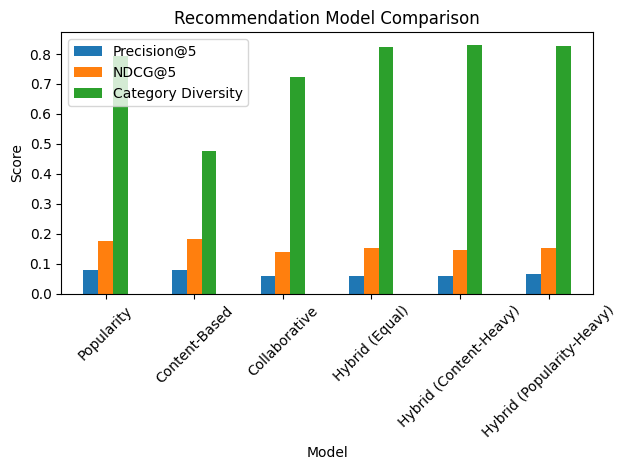

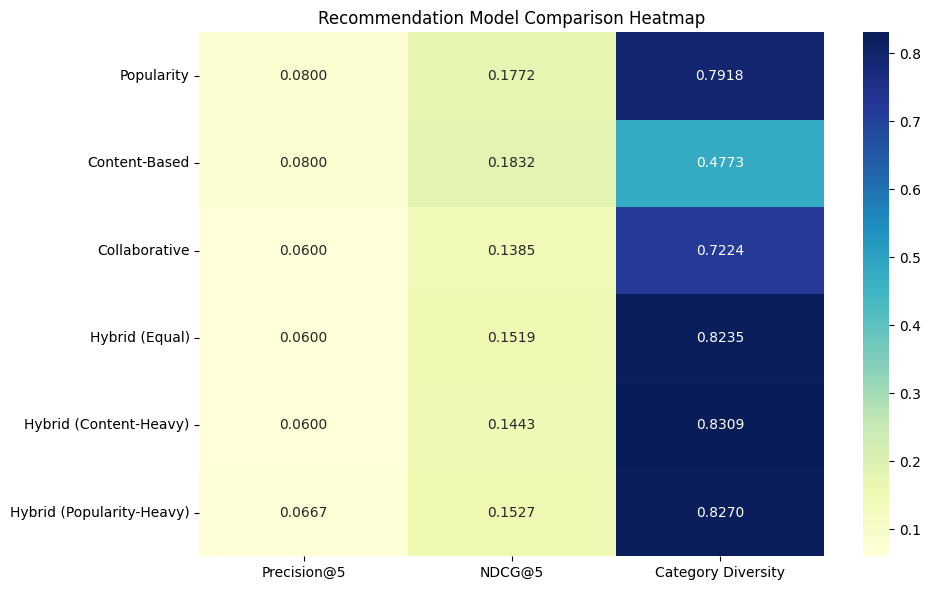

In [ ]:

def compare_recommendation_models(behaviors_df, news_df):
    """Compare different recommendation models in a tabular format."""
    # Create train/test split
    train_df, test_df = improved_temporal_split(behaviors_df, test_size=0.2, min_history=3)
    
    # Build recommendation components
    print("Building recommendation components...")
    popularity_dict = build_popularity_recommender(train_df, news_df)
    tfidf_matrix, tfidf_vectorizer, news_indices = improved_content_based_recommender(news_df)
    user_item_matrix, user_mapping, item_mapping, svd_model = improved_collaborative_filtering(train_df)
    
    # Get test users
    test_clicks = test_df[test_df['label'] == 1]
    test_users = test_clicks['user_id'].unique()
    sample_users = np.random.choice(test_users, min(30, len(test_users)), replace=False)
    
    # Define models to compare
    models = {
        'Popularity': {'weights': (1.0, 0.0, 0.0)},
        'Content-Based': {'weights': (0.0, 1.0, 0.0)},
        'Collaborative': {'weights': (0.0, 0.0, 1.0)},
        'Hybrid (Equal)': {'weights': (0.33, 0.33, 0.34)},
        'Hybrid (Content-Heavy)': {'weights': (0.2, 0.5, 0.3)},
        'Hybrid (Popularity-Heavy)': {'weights': (0.5, 0.3, 0.2)}
    }
    
    results = {}
    
    # Test each model
    for model_name, config in models.items():
        print(f"Testing {model_name} model...")
        model_results = []
        
        for user_id in sample_users:
            # Get user history
            user_train = train_df[train_df['user_id'] == user_id]
            clicked_articles = user_train[user_train['label'] == 1]['news_id'].tolist()
            
            history_lists = user_train['history'].tolist()
            for history_list in history_lists:
                if isinstance(history_list, list):
                    clicked_articles.extend(history_list)
            
            user_history = list(set(clicked_articles))
            
            # Get test data
            user_test = test_df[test_df['user_id'] == user_id]
            actual_clicks = user_test[user_test['label'] == 1]['news_id'].tolist()
            current_impressions = user_test['news_id'].tolist()
            
            # Skip users with no test impressions or clicks
            if not current_impressions or not actual_clicks:
                continue
            
            # Generate recommendations with specified weights
            recommendations = improved_hybrid_recommendations(
                user_id, user_history, 
                popularity_dict,
                tfidf_matrix, 
                news_indices,
                news_df,
                user_item_matrix, 
                user_mapping, 
                item_mapping, 
                svd_model,
                train_df, weights=config['weights'], top_n=10,
                include_categories=True,
                current_impressions=current_impressions
            )
            
            # Evaluate recommendations
            metrics = evaluate_recommendations(
                recommendations,
                actual_clicks,
                current_impressions,
                news_df,
                popularity_dict
            )
            
            model_results.append({
                'precision@5': metrics.get('Precision@5', 0),
                'ndcg@5': metrics.get('NDCG@5', 0),
                'diversity': metrics.get('Category Entropy', 0)
            })
        
        # Calculate average metrics
        if model_results:
            results[model_name] = {
                'precision@5': sum(r['precision@5'] for r in model_results) / len(model_results),
                'ndcg@5': sum(r['ndcg@5'] for r in model_results) / len(model_results),
                'diversity': sum(r['diversity'] for r in model_results) / len(model_results),
                'count': len(model_results)
            }
        else:
            results[model_name] = {
                'precision@5': 0, 'ndcg@5': 0, 'diversity': 0, 'count': 0
            }
    
    # Create a DataFrame for easy comparison
    comparison_df = pd.DataFrame({
        model: {
            'Precision@5': results[model]['precision@5'],
            'NDCG@5': results[model]['ndcg@5'],
            'Category Diversity': results[model]['diversity'],
            'Sample Size': results[model]['count']
        } for model in models.keys()
    }).T
    
    return comparison_df

# Run the comparison
comparison_results = compare_recommendation_models(behaviors_df, news_df)

# Display the results
print("\nModel Comparison Results:")
print(comparison_results)

# Create a bar chart to visualize the comparison
plt.figure(figsize=(12, 8))
comparison_results[['Precision@5', 'NDCG@5', 'Category Diversity']].plot(kind='bar')
plt.title('Recommendation Model Comparison')
plt.ylabel('Score')
plt.xlabel('Model')
plt.xticks(rotation=45)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# Create a heatmap for better visualization
plt.figure(figsize=(10, 6))
sns.heatmap(comparison_results[['Precision@5', 'NDCG@5', 'Category Diversity']], 
            annot=True, cmap='YlGnBu', fmt='.4f')
plt.title('Recommendation Model Comparison Heatmap')
plt.tight_layout()
plt.show()
